# OSM -> Stockholm motor-flow — match report

Enriches the OSM `driving.edges` network with Stockholm's open **Trafikflöde Motorfordon**
(weekday avg daily traffic, 2014–2015). See `docs/stockholm_flow_matching.md`. Steps:

1. **Match** — `run_match_routes(flow, osm)` (OSM = source) → `routes_summary` (route-level per edge)
   + `routes_long` (per edge × flow segment).
2. **Filter twins** — per twin pair, drop the edge with the lower **route-level** quality
   (`routes_summary`); the survivors are the *remaining edges*.
3. **Resolve** — for the survivors, from `routes_long`: `source_flow_id` = the flow segment covering
   the most of the edge; `covering_match` = `edge_cover_pct`; `quality_match` = **edge-to-edge** score.
4. **Extend** — copy the survivor's match to its dropped twin (`match_source`: `best` / `extended`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))

import duckdb
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline

from scripts.stockholm_flow import (match_scored, resolve_twins, write_match,
                                     format_report, OSM_DB, SRC_DB, OUT_TABLE)

pd.set_option("display.max_rows", 60)

def con_ro():
    c = duckdb.connect(str(OSM_DB), read_only=True)
    c.execute("INSTALL spatial"); c.execute("LOAD spatial")
    return c

## Step 1 — match; score for the twin filter and edge-to-edge

`match_scored()` returns `scored` (per matched edge: best-cover flow from `routes_long` with edge-to-edge `covering_match` / `quality_match`) and `route_quality` (per edge, route-level quality from `routes_summary`, used only to pick the surviving twin).

In [2]:
scored, route_quality, rep = match_scored()
rq = pd.Series(route_quality, name="route_quality")
print(f"OSM edges with a route: {len(scored):,} / {rep['osm_edges']:,}")
print(f"route_quality > 0 (matched in routes_summary): {(rq > 0).sum():,}")
scored.head()

OSM edges with a route: 1,967 / 4,554
route_quality > 0 (matched in routes_summary): 1,934


,source_flow_id,covering_match,quality_match
osm_edge_id,,,
1,Trafikflode_Motorfordon.8545,100.0,81.6
3,Trafikflode_Motorfordon.11350,92.3,85.3
5,Trafikflode_Motorfordon.7451,99.8,88.6
7,Trafikflode_Motorfordon.11347,99.1,88.9
9,Trafikflode_Motorfordon.4514,76.8,74.7


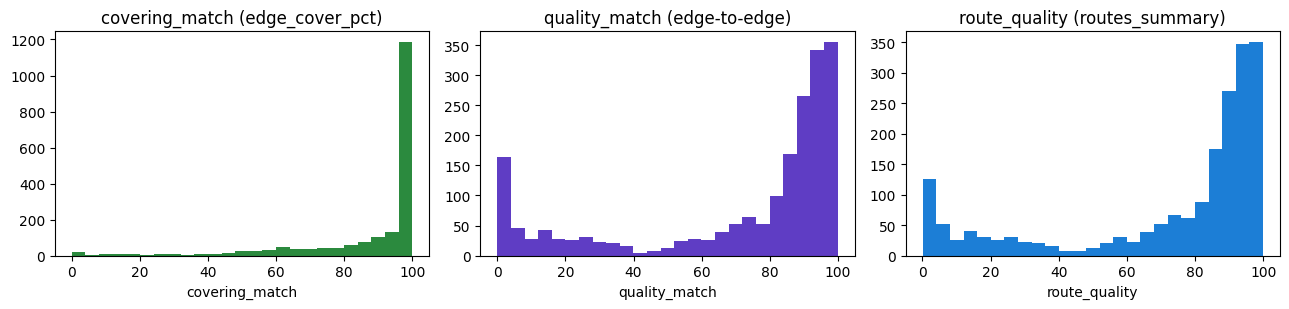

,covering_match,quality_match
count,1967.00,1967.00
mean,87.95,70.94
std,21.06,33.02
min,0.00,0.00
25%,85.60,58.15
50%,99.00,87.50
75%,100.00,94.50
max,100.00,99.90


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(scored.covering_match, bins=25, color="#2b8a3e"); axes[0].set(title="covering_match (edge_cover_pct)", xlabel="covering_match")
axes[1].hist(scored.quality_match, bins=25, color="#5f3dc4"); axes[1].set(title="quality_match (edge-to-edge)", xlabel="quality_match")
axes[2].hist(rq[rq > 0], bins=25, color="#1c7ed6"); axes[2].set(title="route_quality (routes_summary)", xlabel="route_quality")
plt.tight_layout(); plt.show()
scored[["covering_match", "quality_match"]].describe().round(2)

## Steps 2–4 — filter twins (routes_summary), resolve & extend

`resolve_twins()` keeps the higher route-quality twin, copies its edge-to-edge match to both. Blekingegatan: the reverse edge aligns with the flow and wins (`best`); the forward edge had no route and is `extended`. Both twins then carry the same segment / cover / quality.

In [4]:
final = resolve_twins(scored, route_quality)
n = write_match(final)
rep = {**rep, "edges_enriched": len(final),
       "best": int((final.match_source == 'best').sum()),
       "extended": int((final.match_source == 'extended').sum())}
print("\n".join(format_report(rep)))
print(f"\nwrote {OUT_TABLE}: {n:,} rows")
print("match_source:", final.match_source.value_counts().to_dict())

print("\n--- Blekingegatan twins (8 fwd, 3029 rev) ---")
display(final[final.edge_id.isin([8, 3029])].sort_values("is_reverse"))

c = con_ro()
tw = c.execute(f'''
WITH ek AS (SELECT edge_id,is_reverse,osm_id,least(source,target) a,greatest(source,target) b FROM driving.edges),
pairs AS (SELECT osm_id,a,b, MAX(CASE WHEN NOT is_reverse THEN edge_id END) fwd,
                              MAX(CASE WHEN is_reverse THEN edge_id END) rev FROM ek GROUP BY osm_id,a,b),
tw AS (SELECT * FROM pairs WHERE fwd IS NOT NULL AND rev IS NOT NULL)
SELECT COUNT(*) twoway_pairs,
       COUNT(*) FILTER (WHERE mf.edge_id IS NOT NULL AND mr.edge_id IS NOT NULL) both_present,
       COUNT(*) FILTER (WHERE mf.source_flow_id=mr.source_flow_id) same_segment,
       COUNT(*) FILTER (WHERE mf.quality_match=mr.quality_match) same_quality
FROM tw LEFT JOIN {OUT_TABLE} mf ON mf.edge_id=tw.fwd
        LEFT JOIN {OUT_TABLE} mr ON mr.edge_id=tw.rev''').df()
c.close()
tw.T.rename(columns={0: "pairs"})

  Match (OSM -> flow; routes_summary twin filter -> routes_long extend):
    flow segments        : 976
    OSM edges            : 4,554
    matched (raw)        : 1,967
    enriched (best+ext)  : 2,955 (65%)
      best / extended    : 1,887 / 1,068

wrote edge_stockholm_flow_match: 2,955 rows
match_source: {'best': 1887, 'extended': 1068}

--- Blekingegatan twins (8 fwd, 3029 rev) ---


,edge_id,is_reverse,source_flow_id,covering_match,quality_match,match_source
129,8,False,Trafikflode_Motorfordon.2920,88.6,83.6,extended
130,3029,True,Trafikflode_Motorfordon.2920,88.6,83.6,best


,pairs
twoway_pairs,1533
both_present,1064
same_segment,1064
same_quality,1064


## Coverage by OSM highway class

Arterials should be well covered; `service` is low (not in Stockholm's car-network *Bilnät* layer).

,highway,matched,total,matched_pct
0,trunk,15,15,100.0
1,trunk_link,14,14,100.0
2,primary,8,21,38.1
3,primary_link,4,8,50.0
4,secondary,124,173,71.7
5,secondary_link,8,10,80.0
6,tertiary,209,309,67.6
7,tertiary_link,4,4,100.0
8,unclassified,59,113,52.2
9,residential,1226,1821,67.3


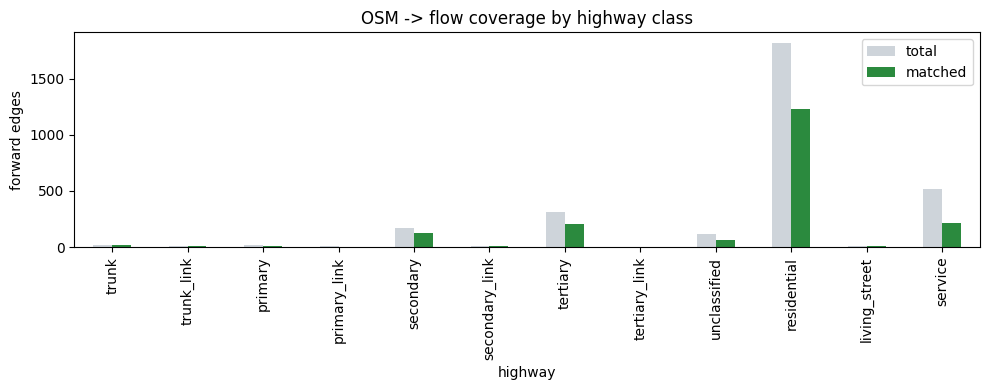

In [5]:
c = con_ro()
cov = c.execute(f'''
    SELECT e.highway, COUNT(*) FILTER (WHERE m.edge_id IS NOT NULL) AS matched, COUNT(*) AS total
    FROM driving.edges e LEFT JOIN {OUT_TABLE} m USING (edge_id)
    WHERE NOT e.is_reverse GROUP BY e.highway''').df()
c.close()
ORDER = ["motorway","motorway_link","trunk","trunk_link","primary","primary_link","secondary",
         "secondary_link","tertiary","tertiary_link","unclassified","residential","living_street","service"]
cov["matched_pct"] = (100*cov.matched/cov.total).round(1)
cov["_o"] = cov.highway.apply(lambda h: ORDER.index(h) if h in ORDER else 99)
cov = cov.sort_values("_o").drop(columns="_o").reset_index(drop=True)
display(cov)
ax = cov.set_index("highway")[["total","matched"]].plot.bar(figsize=(10,4), color=["#ced4da","#2b8a3e"])
ax.set_ylabel("forward edges"); ax.set_title("OSM -> flow coverage by highway class")
plt.tight_layout(); plt.show()

## Map — matched edges by flow

Matched OSM edges colored + width-scaled by `flow_all_vehicles` (joined from the source table; plasma, 0->p95). Geometry simplified (~3 m); saved to `output/sodermalm_flow_match.html`.

In [6]:
import folium
import branca.colormap as cm

c = con_ro()
c.execute(f"ATTACH '{SRC_DB}' AS src (READ_ONLY)")
g = c.execute(f'''
    SELECT m.edge_id, e.name AS street_name, f.flow_all_vehicles, m.covering_match, m.quality_match, m.match_source,
           ST_AsText(ST_Simplify(ST_Force2D(e.geometry), 0.00003)) AS w
    FROM {OUT_TABLE} m
    JOIN driving.edges e USING (edge_id)
    JOIN src.stockholm_motor_flow f ON f.id = m.source_flow_id''').df()
c.close()

gdf = gpd.GeoDataFrame(g.drop(columns="w"), geometry=gpd.GeoSeries.from_wkt(g.w), crs="EPSG:4326")
vmax = float(gdf.flow_all_vehicles.quantile(0.95))
ramp = cm.linear.plasma.scale(0, vmax); ramp.caption = "flow_all_vehicles (veh/weekday)"
ctr = gdf.geometry.union_all().centroid
fmap = folium.Map(location=[ctr.y, ctr.x], zoom_start=14, tiles="cartodbdark_matter")

def _style(feat):
    v = min(feat["properties"]["flow_all_vehicles"], vmax)
    return {"color": ramp(v), "weight": 1.5 + 7*v/vmax, "opacity": 0.9}

folium.GeoJson(gdf.__geo_interface__, style_function=_style,
               tooltip=folium.GeoJsonTooltip(fields=["street_name","flow_all_vehicles","covering_match","quality_match","match_source"])).add_to(fmap)
ramp.add_to(fmap)
fmap.save(str(ROOT / "output" / "sodermalm_flow_match.html"))
print("saved output/sodermalm_flow_match.html")
fmap

saved output/sodermalm_flow_match.html
